### LOAD DATA

In [1]:
import glob
import os
import gc
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


outdir = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS_tune_5min_1800_1hrs/"

# Find all truth member files
file_pattern = os.path.join(outdir, "*_sweep_*_tm*.npz")
all_files = glob.glob(file_pattern)
all_files.sort()

print(f"Found {len(all_files)} files. Commencing load...")

# Restrict loaded keys to save memory (~7.5M rows is heavy)
keys_to_extract = [
    'i', 'j', 'k', 'method', 'ntemp', 'alpha_s', 
    'yo_clean', 'yo', 'hxf_mean_obs', 
    'rmse_f_point_obs', 'rmse_a_point_obs', 
    'dep_b', 'dep_a', 'spread_f_obs', 'spread_a_obs'
]

df_list = []
for f in all_files:
    # Extract the truth member ID from the filename
    tm_str = f.split('_tm')[-1].split('.')[0]
    
    try:
        data = np.load(f, allow_pickle=True)
        df_temp = pd.DataFrame({k: data[k] for k in keys_to_extract})
        df_temp['tm'] = int(tm_str) # Track the truth member realization
        df_list.append(df_temp)
    except Exception as e:
        print(f"Error loading {f}: {e}")

# Concatenate into one massive DataFrame
df_full = pd.concat(df_list, ignore_index=True)

# Separate out TEnKF and compute our core metrics globally
df_tenkf_full = df_full[df_full['method'] == 'TEnKF'].copy()
df_tenkf_full['delta_rmse'] = df_tenkf_full['rmse_f_point_obs'] - df_tenkf_full['rmse_a_point_obs']
df_tenkf_full['abs_innovation'] = df_tenkf_full['dep_b'].abs()

# Free raw data — no longer needed
del df_list, df_full
gc.collect()

# Downcast to float32 / int32 to halve memory (~3-4 GB saved)
_float_cols = ['yo_clean', 'yo', 'hxf_mean_obs',
               'rmse_f_point_obs', 'rmse_a_point_obs',
               'dep_b', 'dep_a', 'spread_f_obs', 'spread_a_obs',
               'delta_rmse', 'abs_innovation']
df_tenkf_full[_float_cols] = df_tenkf_full[_float_cols].astype(np.float32)

_int_cols = ['i', 'j', 'k', 'ntemp', 'tm']
df_tenkf_full[_int_cols] = df_tenkf_full[_int_cols].astype(np.int32)

print(f"Total TEnKF points loaded across {len(all_files)} realizations: {len(df_tenkf_full):,}")

Found 60 files. Commencing load...
Total TEnKF points loaded across 60 realizations: 24,509,430


In [2]:

# 1. Isolate the LETKF baseline from the full dataset
# alpha_s has no effect on ntemp=1 (no tempering), so restrict to one value;
# using all alpha_s values would cause a Cartesian explosion in the merge below.
_one_alpha = sorted(df_tenkf_full['alpha_s'].unique())[0]
df_letkf_full = df_tenkf_full[
    (df_tenkf_full['ntemp'] == 1) & (df_tenkf_full['alpha_s'] == _one_alpha)
][['tm', 'i', 'j', 'k', 'rmse_a_point_obs', 'dep_a', 'spread_a_obs']].copy()
df_letkf_full.rename(columns={
    'rmse_a_point_obs': 'rmse_a_letkf', 
    'dep_a': 'dep_a_letkf', 
    'spread_a_obs': 'spread_a_letkf'
}, inplace=True)

# 2. Merge baseline back into the multi-step TEnKF dataframe
# CRITICAL: We must merge on 'tm' (truth member) alongside 'i', 'j', 'k'
df_multi_full = df_tenkf_full[df_tenkf_full['ntemp'] > 1].copy()
df_multi_full = df_multi_full.merge(df_letkf_full, on=['tm', 'i', 'j', 'k'], how='left')

del df_letkf_full
gc.collect()

# 3. Calculate metrics for the plots
df_multi_full['tenkf_advantage'] = df_multi_full['rmse_a_letkf'] - df_multi_full['rmse_a_point_obs']
df_multi_full['dX_spread'] = df_multi_full['spread_a_obs'] - df_multi_full['spread_a_letkf']
df_multi_full['dY_error'] = df_multi_full['dep_a'] - df_multi_full['dep_a_letkf']
df_multi_full['improvement'] = df_multi_full['dep_a_letkf'].abs() - df_multi_full['dep_a'].abs()

# Extract grid parameters
ntemps = sorted(df_multi_full['ntemp'].unique())
alphas = sorted(df_multi_full['alpha_s'].unique(), reverse=True)[1:]

print(f"Prepared full dataset for 2D analysis. Total multi-step rows: {len(df_multi_full):,}")

Prepared full dataset for 2D analysis. Total multi-step rows: 44,116,974


### Hexbin OBS vs $H(x_f)$

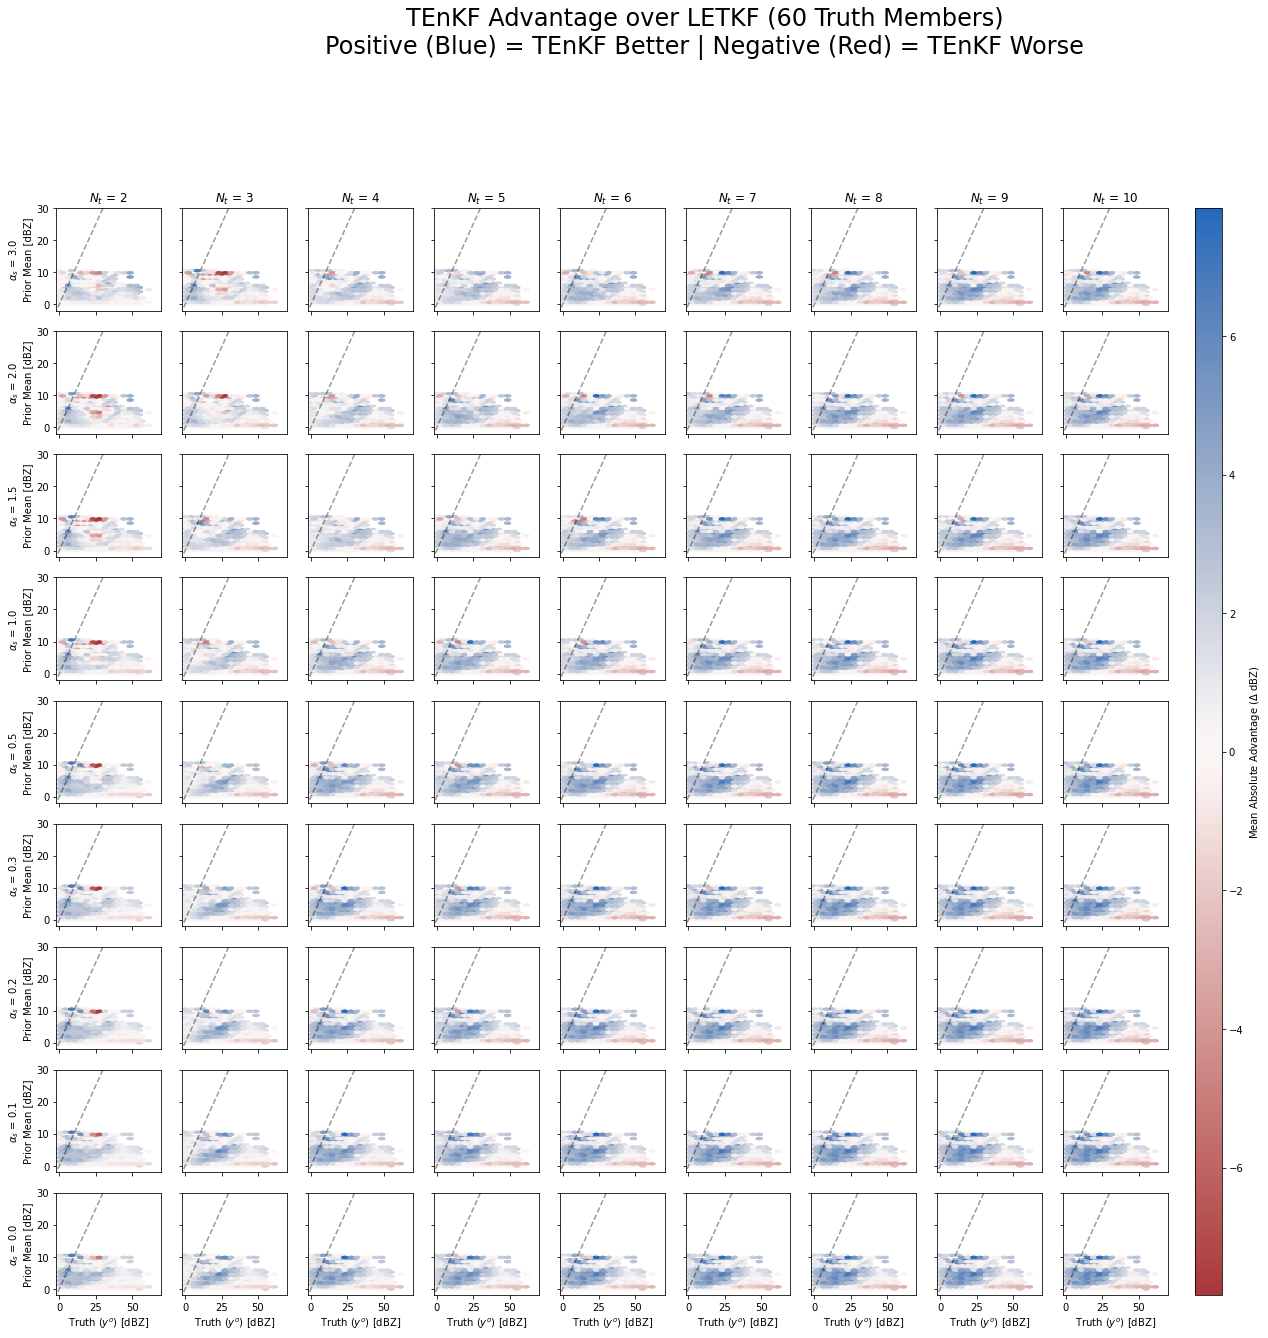

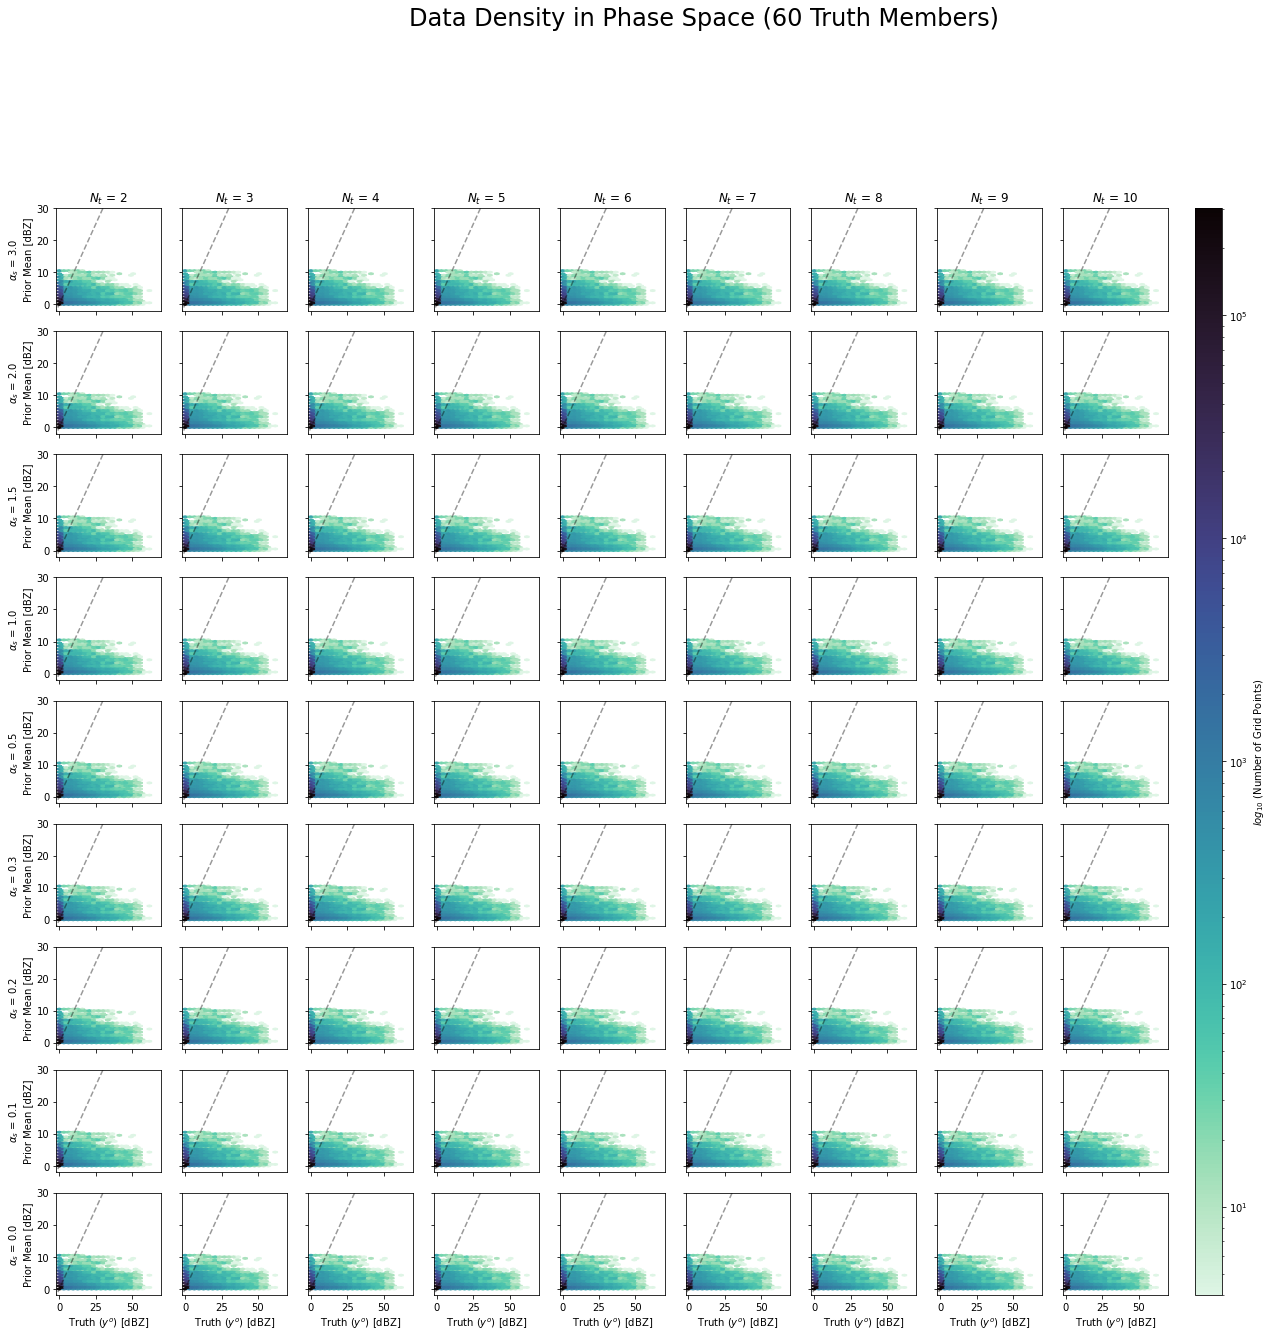

In [3]:
# ==========================================
# Phase Space Hexbins (Full Dataset)
# ==========================================
v_max = np.nanpercentile(np.abs(df_multi_full['tenkf_advantage']), 95) # Tightened percentile for the massive dataset

# 1. TEnKF Advantage Plot
fig1, axes1 = plt.subplots(len(alphas), len(ntemps), figsize=(24, 20), sharex=True, sharey=True)
fig1.suptitle('TEnKF Advantage over LETKF (60 Truth Members)\nPositive (Blue) = TEnKF Better | Negative (Red) = TEnKF Worse', fontsize=24, y=1.02)

cmap_adv = sns.color_palette("vlag_r", as_cmap=True)

for i, alpha_val in enumerate(alphas):
    for j, ntemp_val in enumerate(ntemps):
        ax = axes1[i, j]
        df_panel = df_multi_full[(df_multi_full['alpha_s'] == alpha_val) & (df_multi_full['ntemp'] == ntemp_val)]
        
        if len(df_panel) > 0:
            hb = ax.hexbin(df_panel['yo_clean'], df_panel['hxf_mean_obs'], 
                           C=df_panel['tenkf_advantage'], reduce_C_function=np.mean,
                           gridsize=15, cmap=cmap_adv, vmin=-v_max, vmax=v_max, mincnt=1) # mincnt raised to 10 to filter extreme outliers
            
        ax.plot([-10, 60], [-10, 60], 'k--', alpha=0.4, linewidth=1.5)
        ax.set_xlim([-2, 70])
        ax.set_ylim([-2, 30])
        if i == len(alphas) - 1: ax.set_xlabel(f'Truth ($y^o$) [dBZ]')
        if j == 0: ax.set_ylabel(f'$\\alpha_s$ = {alpha_val:.1f}\nPrior Mean [dBZ]')
        if i == 0: ax.set_title(f'$N_t$ = {ntemp_val}')

cb1 = fig1.colorbar(hb, ax=axes1.ravel().tolist(), pad=0.02, aspect=40)
cb1.set_label(r'Mean Absolute Advantage ($\Delta$ dBZ)')
plt.show()

# 2. Data Density Plot
fig2, axes2 = plt.subplots(len(alphas), len(ntemps), figsize=(24, 20), sharex=True, sharey=True)
fig2.suptitle('Data Density in Phase Space (60 Truth Members)', fontsize=24, y=1.02)
cmap_dens = sns.color_palette("mako_r", as_cmap=True)

for i, alpha_val in enumerate(alphas):
    for j, ntemp_val in enumerate(ntemps):
        ax = axes2[i, j]
        df_panel = df_multi_full[(df_multi_full['alpha_s'] == alpha_val) & (df_multi_full['ntemp'] == ntemp_val)]
        
        if len(df_panel) > 0:
            hb2 = ax.hexbin(df_panel['yo_clean'], df_panel['hxf_mean_obs'], 
                            gridsize=20, cmap=cmap_dens, bins='log', mincnt=1)
            
        ax.plot([-10, 60], [-10, 60], 'k--', alpha=0.4, linewidth=1.5)
        ax.set_xlim([-2, 70])
        ax.set_ylim([-2, 30])
        if i == len(alphas) - 1: ax.set_xlabel(f'Truth ($y^o$) [dBZ]')
        if j == 0: ax.set_ylabel(f'$\\alpha_s$ = {alpha_val:.1f}\nPrior Mean [dBZ]')
        if i == 0: ax.set_title(f'$N_t$ = {ntemp_val}')

cb2 = fig2.colorbar(hb2, ax=axes2.ravel().tolist(), pad=0.02, aspect=40)
cb2.set_label(r'$log_{10}$ (Number of Grid Points)')
plt.show()

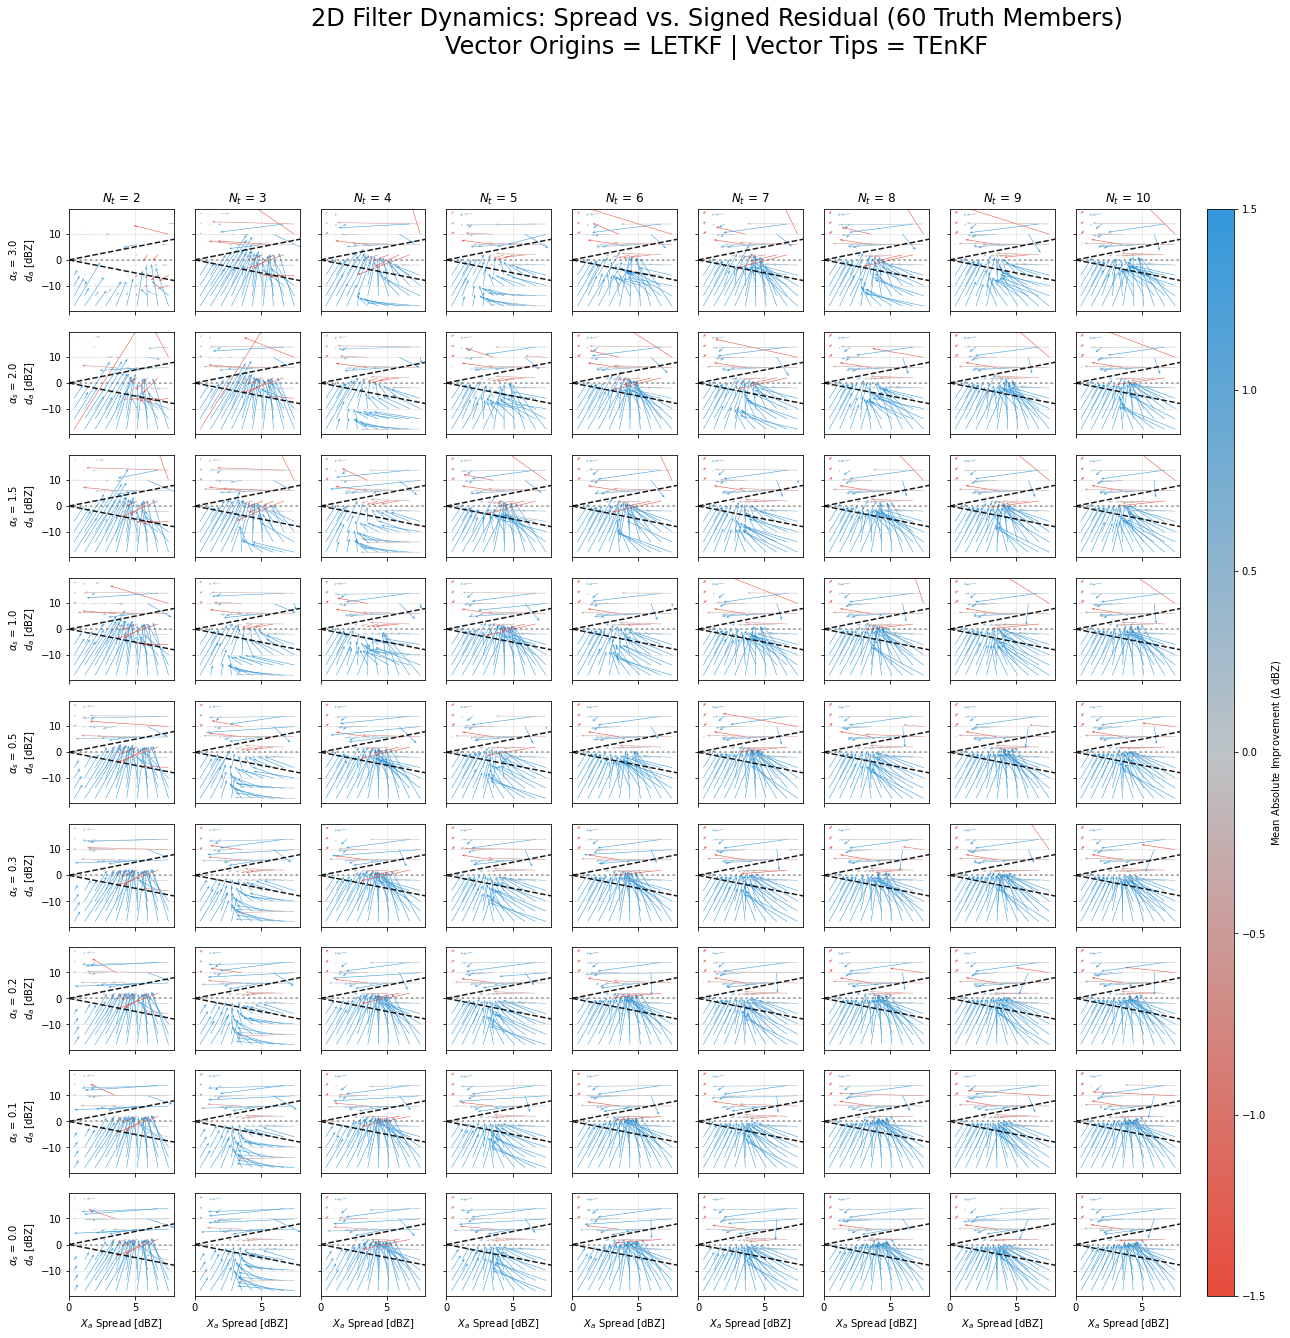

In [4]:
# ==========================================
# Vector Flow: Spread vs Signed Residual (Full Dataset)
# ==========================================
max_spread = np.nanpercentile(df_multi_full['spread_a_letkf'], 99)
lim_max_err = np.nanpercentile(np.abs(df_multi_full['dep_a_letkf']), 99)
axis_lim_err = [-lim_max_err, lim_max_err]

bins = 10 # Kept relatively coarse for vector visibility

fig, axes = plt.subplots(len(alphas), len(ntemps), figsize=(24, 20), sharex=True, sharey=True)
fig.suptitle('2D Filter Dynamics: Spread vs. Signed Residual (60 Truth Members)\n'
             'Vector Origins = LETKF | Vector Tips = TEnKF', 
             fontsize=24, y=1.02)

cmap_quiver = mcolors.LinearSegmentedColormap.from_list("red_blue", ["#e74c3c", "#bdc3c7", "#3498db"])
norm_quiver = mcolors.TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.5)

for i, alpha_val in enumerate(alphas):
    for j, ntemp_val in enumerate(ntemps):
        ax = axes[i, j]
        df_panel = df_multi_full[(df_multi_full['alpha_s'] == alpha_val) & (df_multi_full['ntemp'] == ntemp_val)]
        
        if len(df_panel) > 0:
            stat_U, x_edge, y_edge, _ = stats.binned_statistic_2d(
                df_panel['spread_a_letkf'], df_panel['dep_a_letkf'], df_panel['dX_spread'], 
                statistic='mean', bins=bins, range=[[0, max_spread], axis_lim_err])
                
            stat_V, _, _, _ = stats.binned_statistic_2d(
                df_panel['spread_a_letkf'], df_panel['dep_a_letkf'], df_panel['dY_error'], 
                statistic='mean', bins=bins, range=[[0, max_spread], axis_lim_err])
                
            stat_C, _, _, _ = stats.binned_statistic_2d(
                df_panel['spread_a_letkf'], df_panel['dep_a_letkf'], df_panel['improvement'], 
                statistic='mean', bins=bins, range=[[0, max_spread], axis_lim_err])
            
            # Transpose to align with meshgrid
            stat_U = stat_U.T
            stat_V = stat_V.T
            stat_C = stat_C.T
            
            X, Y = np.meshgrid((x_edge[:-1] + x_edge[1:]) / 2, (y_edge[:-1] + y_edge[1:]) / 2)
            mask = ~np.isnan(stat_U) & ~np.isnan(stat_V)
            
            if np.any(mask):
                q = ax.quiver(X[mask], Y[mask], stat_U[mask], stat_V[mask], stat_C[mask],
                              cmap=cmap_quiver, norm=norm_quiver,
                              angles='xy', scale_units='xy', scale=1, 
                              width=0.005, headwidth=5, headlength=7)
            
        ax.set_xlim([0, max_spread])
        ax.set_ylim(axis_lim_err)
        ax.grid(True, linestyle='-', alpha=0.3)
        ax.axhline(0, color='Dimgrey', linestyle=':', alpha=0.6, linewidth=2) # Perfect update line
        #plot diagonals where dY/dX = 0 (perfect update) and dY/dX = 1 (perfect spread-error match)
        ax.plot([0,lim_max_err], [0, lim_max_err], 'k--', alpha=0.9, linewidth=1.5)
        ax.plot([0,lim_max_err], [0, -lim_max_err], 'k--', alpha=0.9, linewidth=1.5)

        
        if i == len(alphas) - 1: ax.set_xlabel('$X_a$ Spread [dBZ]')
        if j == 0: ax.set_ylabel(f'$\\alpha_s$ = {alpha_val:.1f}\n$d_a$ [dBZ]')
        if i == 0: ax.set_title(f'$N_t$ = {ntemp_val}')

cb = fig.colorbar(q, ax=axes.ravel().tolist(), pad=0.02, aspect=40)
cb.set_label('Mean Absolute Improvement ($\\Delta$ dBZ)')
plt.show()

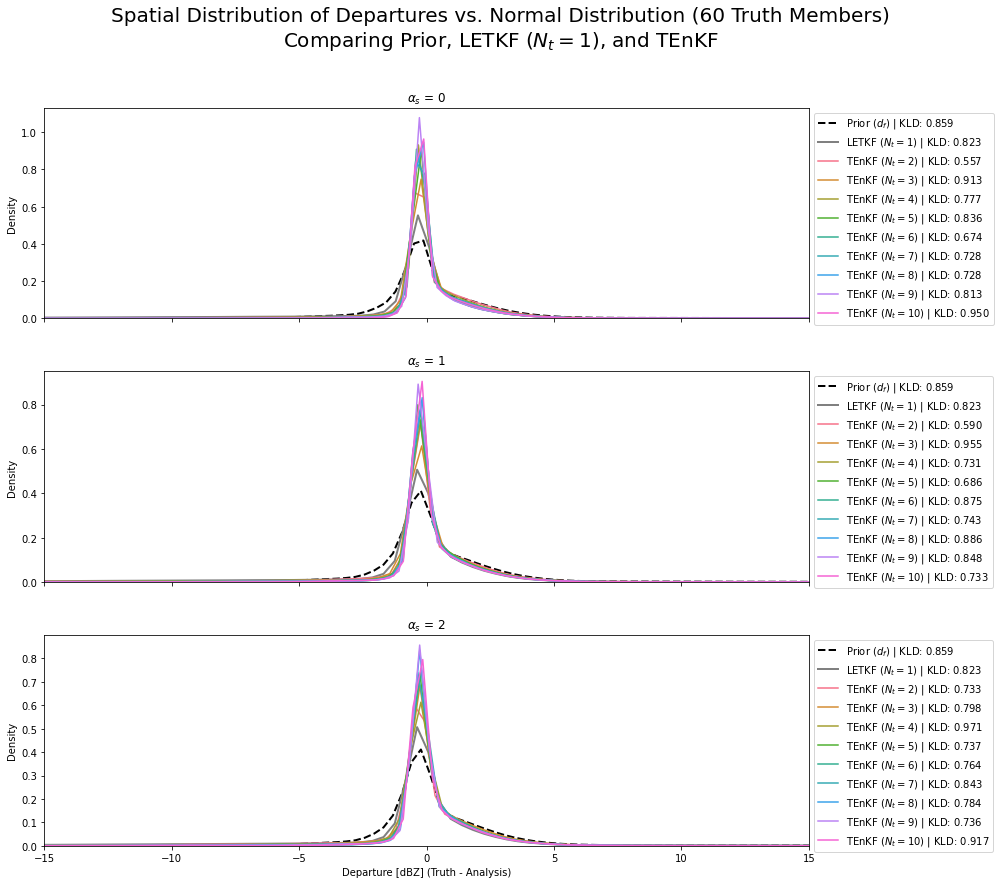

In [5]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to calculate 1D KLD against a fitted Gaussian
def calculate_1d_kld(data_series, bins=100):
    data_clean = data_series.dropna()
    if len(data_clean) < 2: return np.nan
    
    # 1. Get empirical probabilities P(x)
    counts, bin_edges = np.histogram(data_clean, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    mask = counts > 0
    pk = counts[mask]
    valid_centers = bin_centers[mask]
    
    # 2. Get theoretical Gaussian probabilities Q(x)
    mu, std = np.mean(data_clean), np.std(data_clean)
    if std == 0: return np.nan
    qk = stats.norm.pdf(valid_centers, mu, std)
    
    # Normalize
    pk = pk / np.sum(pk)
    qk = qk / np.sum(qk)
    
    # 3. Calculate Divergence
    return stats.entropy(pk, qk)

# Extract alphas and set up the figure
alphas = sorted(df_tenkf_full['alpha_s'].unique(), reverse=True)
alphas = [0,1,2]
fig, axes = plt.subplots(len(alphas), 1, figsize=(14, 4 * len(alphas)), sharex=True)
fig.suptitle('Spatial Distribution of Departures vs. Normal Distribution (60 Truth Members)\nComparing Prior, LETKF ($N_t=1$), and TEnKF', fontsize=20, y=1.02)

palette = sns.color_palette("husl", len(df_tenkf_full['ntemp'].unique()) - 1)

for i, alpha_val in enumerate(alphas):
    ax = axes[i]
    df_alpha = df_tenkf_full[df_tenkf_full['alpha_s'] == alpha_val]
    
    # Plot Prior (dep_b is the same for all rows)
    prior_dep = df_alpha[df_alpha['ntemp'] == 1]['dep_b']
    kld_prior = calculate_1d_kld(prior_dep)
    sns.kdeplot(prior_dep, ax=ax, color='black', linestyle='--', linewidth=2, 
                label=f'Prior ($d_f$) | KLD: {kld_prior:.3f}')
    
    # Plot LETKF (Nt = 1)
    letkf_dep = df_alpha[df_alpha['ntemp'] == 1]['dep_a']
    kld_letkf = calculate_1d_kld(letkf_dep)
    sns.kdeplot(letkf_dep, ax=ax, color='gray', linewidth=2, 
                label=f'LETKF ($N_t=1$) | KLD: {kld_letkf:.3f}')
    
    # Plot TEnKF variations
    for j, ntemp_val in enumerate(sorted(df_alpha['ntemp'].unique())):
        if ntemp_val == 1: continue 
            
        tenkf_dep = df_alpha[df_alpha['ntemp'] == ntemp_val]['dep_a']
        kld_tenkf = calculate_1d_kld(tenkf_dep)
        sns.kdeplot(tenkf_dep, ax=ax, color=palette[j-1], linewidth=1.5,
                    label=f'TEnKF ($N_t={ntemp_val}$) | KLD: {kld_tenkf:.3f}')
    
    ax.set_title(r'$\alpha_s$ = ' + str(alpha_val))
    ax.set_ylabel('Density')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    ax.set_xlim([-15, 15]) # Slightly widened for the 60-member spread

axes[-1].set_xlabel('Departure [dBZ] (Truth - Analysis)')
plt.tight_layout()
plt.show()

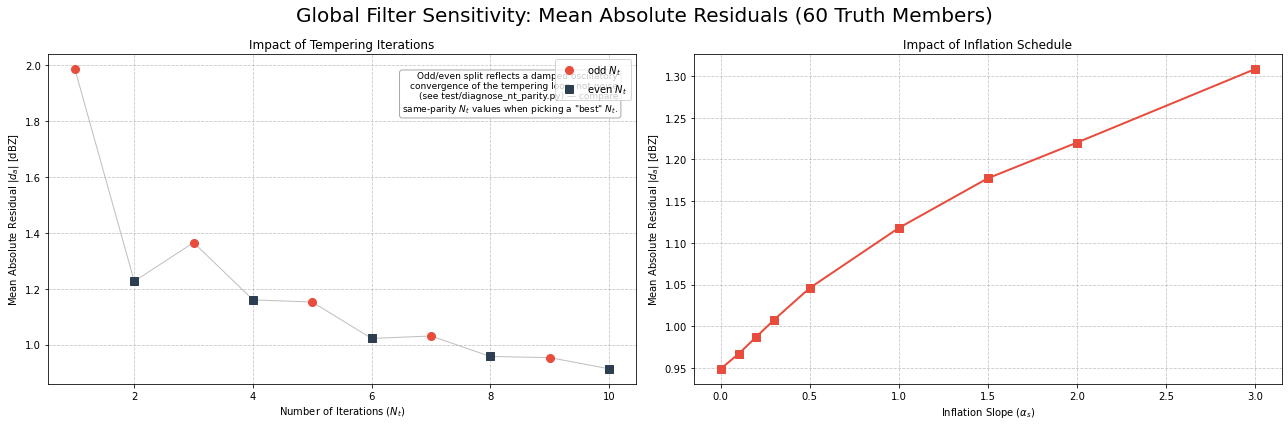

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Global Filter Sensitivity: Mean Absolute Residuals (60 Truth Members)', fontsize=20)

# --- Data cleanup -----------------------------------------------------------
# The sweep config's alpha_s list had a YAML typo ("0,7" instead of "0.7"), which
# parsed into two extra scalars: a duplicate alpha_s=0.0 combo (every point/tm/ntemp
# was run twice at alpha_s=0.0, doubling its weight in the means below) and a stray
# alpha_s=7.0 far outside the intended 0-3 sweep range. Both are removed here so
# Panel 1's Nt>1 mean isn't skewed and Panel 2 doesn't show a bogus extreme point.
_id_cols = ['tm', 'i', 'j', 'k', 'ntemp', 'alpha_s']
df_clean = df_tenkf_full[df_tenkf_full['alpha_s'] != 7.0].drop_duplicates(subset=_id_cols)

# Panel 1: Residual vs Nt (Averaged across all alphas)
mean_res_nt = df_clean.groupby('ntemp')['dep_a'].apply(lambda x: x.abs().mean()).reset_index(name='abs_dep_a')

# NOTE: odd Nt values consistently sit above the preceding even Nt — this is a real,
# reproducible damped oscillatory convergence of the TEnKF tempering loop (confirmed
# in test/diagnose_nt_parity.py: it persists at a single truth member/point/alpha_s,
# is driven mainly by the qr/qs/qg>=0 clipping applied after every sub-step, and its
# amplitude shrinks monotonically with Nt). Odd and even Nt sit on opposite sides of
# that oscillation, so they are split out below rather than compared as one smooth curve.
is_odd = mean_res_nt['ntemp'] % 2 == 1
ax1.plot(mean_res_nt['ntemp'], mean_res_nt['abs_dep_a'], '-', color='0.75', linewidth=1, zorder=1)
ax1.plot(mean_res_nt.loc[is_odd, 'ntemp'], mean_res_nt.loc[is_odd, 'abs_dep_a'],
         marker='o', markersize=8, linewidth=0, color='#e74c3c', label='odd $N_t$', zorder=2)
ax1.plot(mean_res_nt.loc[~is_odd, 'ntemp'], mean_res_nt.loc[~is_odd, 'abs_dep_a'],
         marker='s', markersize=8, linewidth=0, color='#2c3e50', label='even $N_t$', zorder=2)
ax1.set_title('Impact of Tempering Iterations')
ax1.set_xlabel('Number of Iterations ($N_t$)')
ax1.set_ylabel('Mean Absolute Residual $|d_a|$ [dBZ]')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()
ax1.annotate('Odd/even split reflects a damped oscillatory\nconvergence of the tempering loop, not noise\n'
             '(see test/diagnose_nt_parity.py) — compare\nsame-parity $N_t$ values when picking a "best" $N_t$.',
             xy=(0.97, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', ec='0.6', alpha=0.85))

# Panel 2: Residual vs Alpha (Averaged across all Nt > 1)
df_multi_step = df_clean[df_clean['ntemp'] > 1]
mean_res_alpha = df_multi_step.groupby('alpha_s')['dep_a'].apply(lambda x: x.abs().mean()).reset_index(name='abs_dep_a')

ax2.plot(mean_res_alpha['alpha_s'], mean_res_alpha['abs_dep_a'], marker='s', markersize=8, linewidth=2, color='#e74c3c')
ax2.set_title('Impact of Inflation Schedule')
ax2.set_xlabel(r'Inflation Slope ($\alpha_s$)')
ax2.set_ylabel('Mean Absolute Residual $|d_a|$ [dBZ]')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Tempering Schedule Sanity Check

Verify the actual weights `tempering_schedule(Nt, alpha_s)` produces for every (Nt, alpha_s) combo in
the sweep — table of the dominant (last-step) weight fraction, and a figure of the full per-step
schedule shape — to check nothing odd is happening in how alpha_s is turned into per-step obs-error
inflation before blaming the Nt/alpha_s sensitivity results above on it.

Non-monotonic schedules (would be a red flag — none expected):
Empty DataFrame
Columns: [ntemp, alpha_s, w_first, w_last, R_over_alpha_first, R_over_alpha_last, monotonic_increasing]
Index: []


alpha_s,0.0,0.1,0.2,0.3,0.5,1.0,1.5,2.0,3.0
ntemp,,,,,,,,,
2,0.500,0.537,0.574,0.611,0.679,0.818,0.905,0.953,0.989
3,0.333,0.370,0.406,0.441,0.505,0.632,0.721,0.788,0.881
4,0.250,0.283,0.315,0.345,0.400,0.508,0.591,0.659,0.763
5,0.200,0.230,0.258,0.284,0.330,0.423,0.498,0.562,0.666
6,0.167,0.194,0.219,0.241,0.281,0.362,0.430,0.489,0.588
7,0.143,0.168,0.190,0.209,0.244,0.316,0.378,0.432,0.525
8,0.125,0.148,0.167,0.185,0.216,0.281,0.337,0.387,0.473
9,0.111,0.132,0.150,0.166,0.193,0.252,0.304,0.350,0.431
10,0.100,0.119,0.136,0.150,0.175,0.229,0.276,0.319,0.395


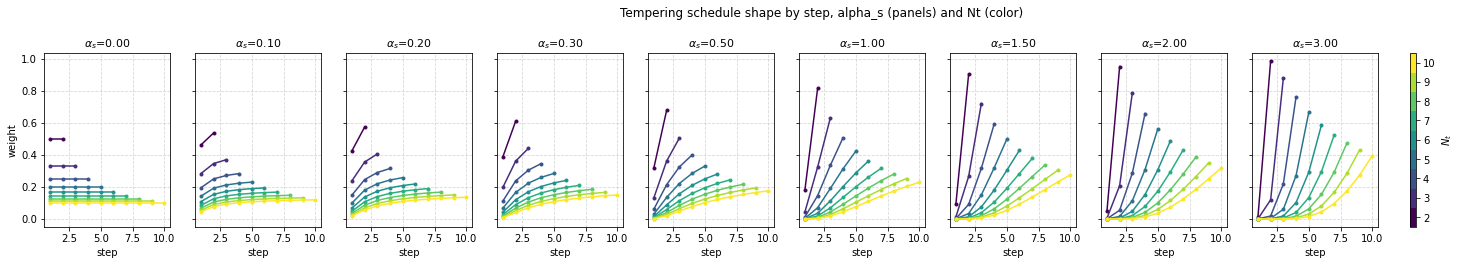

In [7]:
import sys
_SRC = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/src"
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)
from da.core import tempering_schedule

R0 = 5.0  # obs_error_var from the sweep config

ntemps_sched = [nt for nt in sorted(df_clean['ntemp'].unique()) if nt > 1]
alphas_sched = sorted(df_clean['alpha_s'].unique())

# --- Table: dominant (last-step) weight fraction for every (Nt, alpha_s) combo ---
rows = []
for nt in ntemps_sched:
    for a in alphas_sched:
        w = tempering_schedule(int(nt), float(a))
        rows.append({
            'ntemp': int(nt), 'alpha_s': round(float(a), 3),
            'w_first': w[0], 'w_last': w[-1],
            'R_over_alpha_first': R0 / w[0], 'R_over_alpha_last': R0 / w[-1],
            'monotonic_increasing': bool(np.all(np.diff(w) >= -1e-9)),
        })
schedule_df = pd.DataFrame(rows)

print("Non-monotonic schedules (would be a red flag — none expected):")
print(schedule_df[~schedule_df['monotonic_increasing']])

pivot_last = schedule_df.pivot(index='ntemp', columns='alpha_s', values='w_last')
display(pivot_last.style.format('{:.3f}').background_gradient(cmap='viridis')
        .set_caption('Weight fraction carried by the LAST tempering step (w_last), by Nt x alpha_s'))

# --- Figure: full per-step schedule shape, one panel per alpha_s, lines colored by Nt ---
fig, axes = plt.subplots(1, len(alphas_sched), figsize=(3.2 * len(alphas_sched), 3.2),
                          sharey=True)
cmap_nt = plt.get_cmap('viridis', len(ntemps_sched))

for col, a in enumerate(alphas_sched):
    ax = axes[col]
    for i, nt in enumerate(ntemps_sched):
        w = tempering_schedule(int(nt), float(a))
        ax.plot(np.arange(1, nt + 1), w, marker='.', color=cmap_nt(i), linewidth=1.5)
    ax.set_title(f'$\\alpha_s$={a:.2f}', fontsize=11)
    ax.set_xlabel('step')
    ax.grid(True, linestyle='--', alpha=0.5)
axes[0].set_ylabel('weight')

sm = plt.cm.ScalarMappable(cmap=cmap_nt, norm=mcolors.BoundaryNorm(
    np.arange(-0.5, len(ntemps_sched)), len(ntemps_sched)))
sm.set_array([])
cb = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.02, aspect=30)
cb.set_ticks(range(len(ntemps_sched)))
cb.set_ticklabels([str(nt) for nt in ntemps_sched])
cb.set_label('$N_t$')
fig.suptitle('Tempering schedule shape by step, alpha_s (panels) and Nt (color)', y=1.08)
plt.show()

### TEnKF vs Prior (not just vs LETKF)

The hexbin grids above (`tenkf_advantage`) only show whether TEnKF beats **LETKF**. That doesn't tell
us whether TEnKF (or LETKF) actually beats doing nothing — i.e. the **prior/forecast**. A panel can
look "highly beneficial" there just because LETKF was bad, while TEnKF is still worse than the prior;
or "highly bad" there while both are still an improvement over the prior. This section adds that
missing reference by comparing `rmse_a_point_obs` (TEnKF) and `rmse_a_letkf` (LETKF) against
`rmse_f_point_obs` (prior), so the two comparisons can be read side by side.

The LETKF baseline is rebuilt here from `df_clean` (the alpha_s=0.0-deduped, alpha_s=7.0-dropped
frame from the cell above) rather than reusing `df_multi_full`: `df_multi_full`'s merge (cell 2) keys
only on `tm,i,j,k` against a LETKF baseline that still has the duplicate alpha_s=0.0 rows, which
fans the merge out to ~2x rows (harmless for existing means since the duplicates are identical, but
avoided here for a clean 1:1 join).

In [8]:
# Rebuild the LETKF baseline cleanly (see markdown above for why not df_multi_full)
_one_alpha_clean = sorted(df_clean['alpha_s'].unique())[0]
df_letkf_clean = df_clean[
    (df_clean['ntemp'] == 1) & (df_clean['alpha_s'] == _one_alpha_clean)
][['tm', 'i', 'j', 'k', 'rmse_a_point_obs', 'dep_a']].rename(columns={
    'rmse_a_point_obs': 'rmse_a_letkf', 'dep_a': 'dep_a_letkf'})

df_vs_prior = df_clean[df_clean['ntemp'] > 1].merge(
    df_letkf_clean, on=['tm', 'i', 'j', 'k'], how='left')

# Positive = improvement (RMSE went down relative to that baseline)
df_vs_prior['tenkf_vs_letkf'] = df_vs_prior['rmse_a_letkf']     - df_vs_prior['rmse_a_point_obs']
df_vs_prior['tenkf_vs_prior'] = df_vs_prior['rmse_f_point_obs'] - df_vs_prior['rmse_a_point_obs']
df_vs_prior['letkf_vs_prior'] = df_vs_prior['rmse_f_point_obs'] - df_vs_prior['rmse_a_letkf']

print(f"df_vs_prior rows: {len(df_vs_prior):,}  "
      f"(df_multi_full has {len(df_multi_full):,} — ~2x, from the duplicate-alpha merge fanout)")

# Fraction of points where each comparison is an improvement (>0), by Nt.
# letkf_vs_prior doesn't depend on Nt/alpha_s, so it repeats — it's here purely as a
# reference row to eyeball against the other two columns at each Nt.
summary = (df_vs_prior.groupby('ntemp')[['tenkf_vs_letkf', 'tenkf_vs_prior', 'letkf_vs_prior']]
           .apply(lambda g: (g > 0).mean())
           .rename(columns=lambda c: f'frac_{c}_gt0'))
display(summary.style.format('{:.1%}').background_gradient(cmap='RdYlGn', vmin=0, vmax=1)
        .set_caption('Fraction of points where each comparison improves on its baseline, by Nt'))

df_vs_prior rows: 18,047,853  (df_multi_full has 44,116,974 — ~2x, from the duplicate-alpha merge fanout)


,frac_tenkf_vs_letkf_gt0,frac_tenkf_vs_prior_gt0,frac_letkf_vs_prior_gt0
ntemp,,,
2,61.1%,83.8%,78.6%
3,62.6%,80.9%,78.6%
4,63.2%,82.7%,78.6%
5,63.3%,80.4%,78.6%
6,63.4%,81.6%,78.6%
7,63.4%,80.3%,78.6%
8,63.4%,80.8%,78.6%
9,63.3%,80.1%,78.6%
10,63.3%,80.3%,78.6%


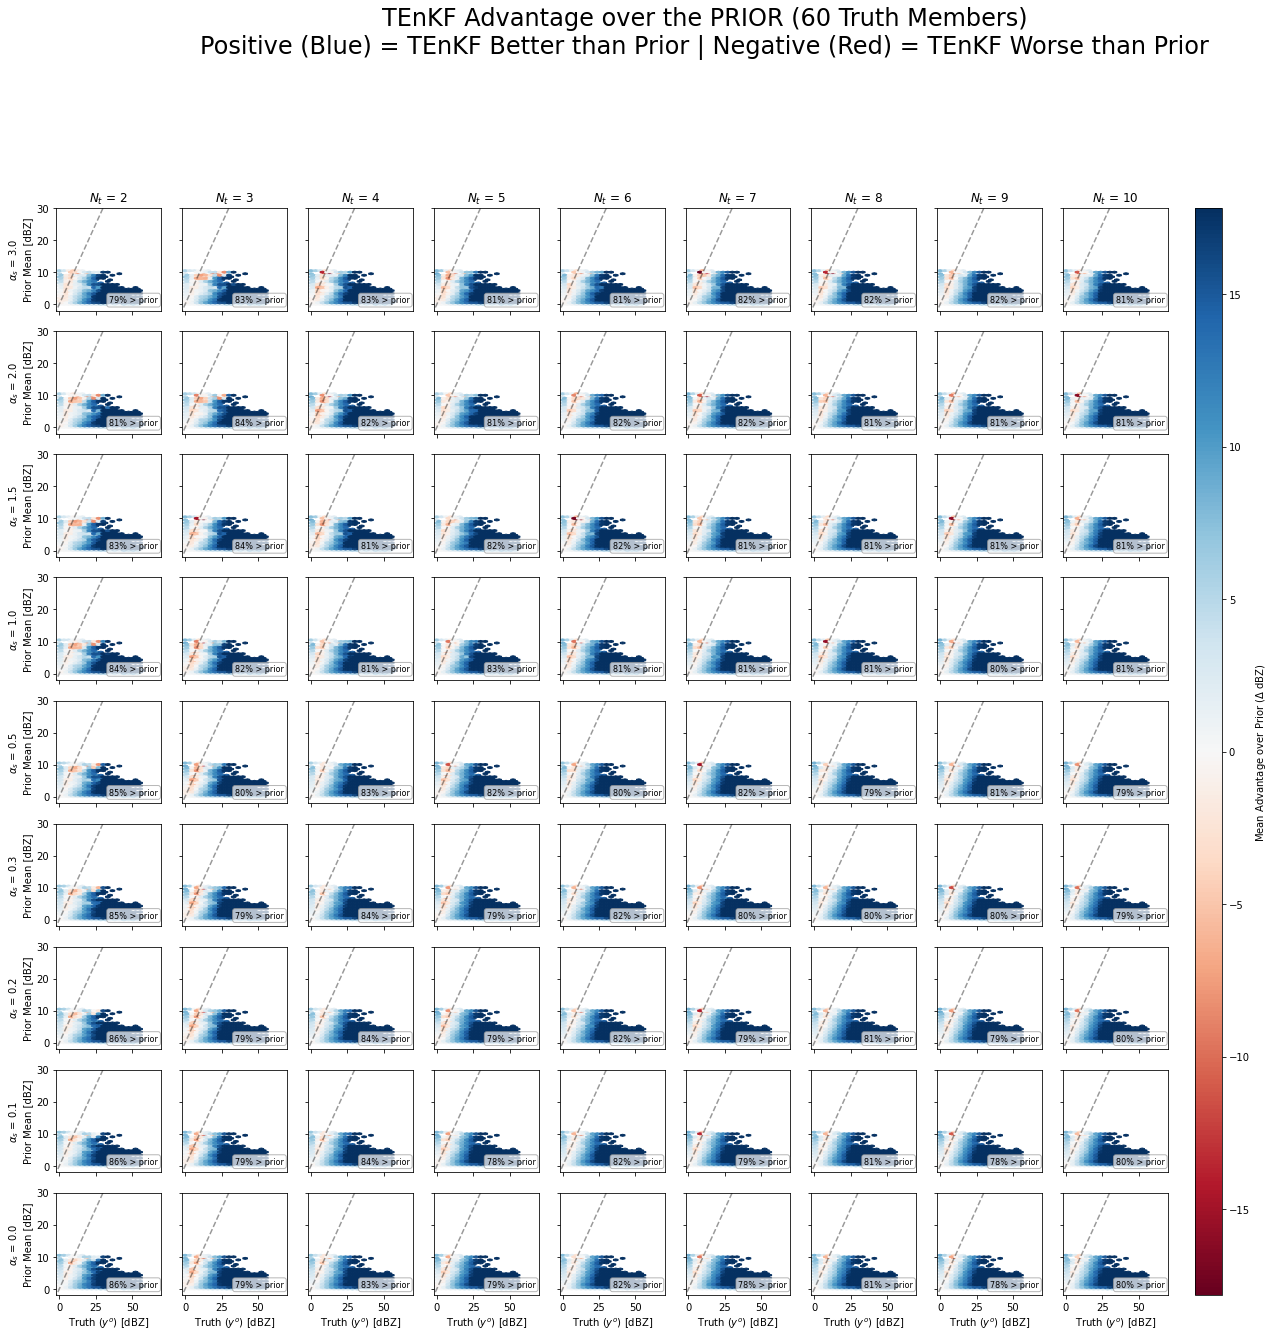

In [18]:
# ==========================================
# TEnKF Advantage over the PRIOR (mirrors the "TEnKF Advantage over LETKF" grid above,
# same axes/binning, colored by tenkf_vs_prior instead) — read the two grids panel-by-panel.
# ==========================================
ntemps_g = sorted(df_vs_prior['ntemp'].unique())
alphas_g = sorted(df_vs_prior['alpha_s'].unique(), reverse=True)

v_max_prior = np.nanpercentile(np.abs(df_vs_prior['tenkf_vs_prior']), 99)

fig3, axes3 = plt.subplots(len(alphas_g), len(ntemps_g), figsize=(24, 20), sharex=True, sharey=True)
fig3.suptitle('TEnKF Advantage over the PRIOR (60 Truth Members)\n'
              'Positive (Blue) = TEnKF Better than Prior | Negative (Red) = TEnKF Worse than Prior',
              fontsize=24, y=1.02)

for i, alpha_val in enumerate(alphas_g):
    for j, ntemp_val in enumerate(ntemps_g):
        ax = axes3[i, j]
        df_panel = df_vs_prior[(df_vs_prior['alpha_s'] == alpha_val) & (df_vs_prior['ntemp'] == ntemp_val)]

        if len(df_panel) > 0:
            hb3 = ax.hexbin(df_panel['yo_clean'], df_panel['hxf_mean_obs'],
                            C=df_panel['tenkf_vs_prior'], reduce_C_function=np.mean,
                            gridsize=20, cmap="RdBu", vmin=-v_max_prior, vmax=v_max_prior, mincnt=1)
            frac = (df_panel['tenkf_vs_prior'] > 0).mean()
            ax.text(0.97, 0.06, f'{frac:.0%} > prior', transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=8,
                    bbox=dict(boxstyle='round', fc='white', alpha=0.7, ec='0.6'))

        ax.plot([-10, 60], [-10, 60], 'k--', alpha=0.4, linewidth=1.5)
        ax.set_xlim([-2, 70])
        ax.set_ylim([-2, 30])
        if i == len(alphas_g) - 1: ax.set_xlabel('Truth ($y^o$) [dBZ]')
        if j == 0: ax.set_ylabel(f'$\\alpha_s$ = {alpha_val:.1f}\nPrior Mean [dBZ]')
        if i == 0: ax.set_title(f'$N_t$ = {ntemp_val}')

cb3 = fig3.colorbar(hb3, ax=axes3.ravel().tolist(), pad=0.02, aspect=40)
cb3.set_label(r'Mean Advantage over Prior ($\Delta$ dBZ)')
plt.show()

### Residual Distributions by $N_t$ (histogram "violins")

The sawtooth curve above (and the summary table two cells up) only show the **mean**. A mean can hide
a skewed or bimodal distribution, which matters for judging whether tempering is actually good or bad.
This is a split histogram at each $N_t$ — left half = baseline (LETKF or prior), right half = TEnKF,
both drawn as plain histograms (bar heights = counts), not KDE, so no smoothing hides the actual shape.

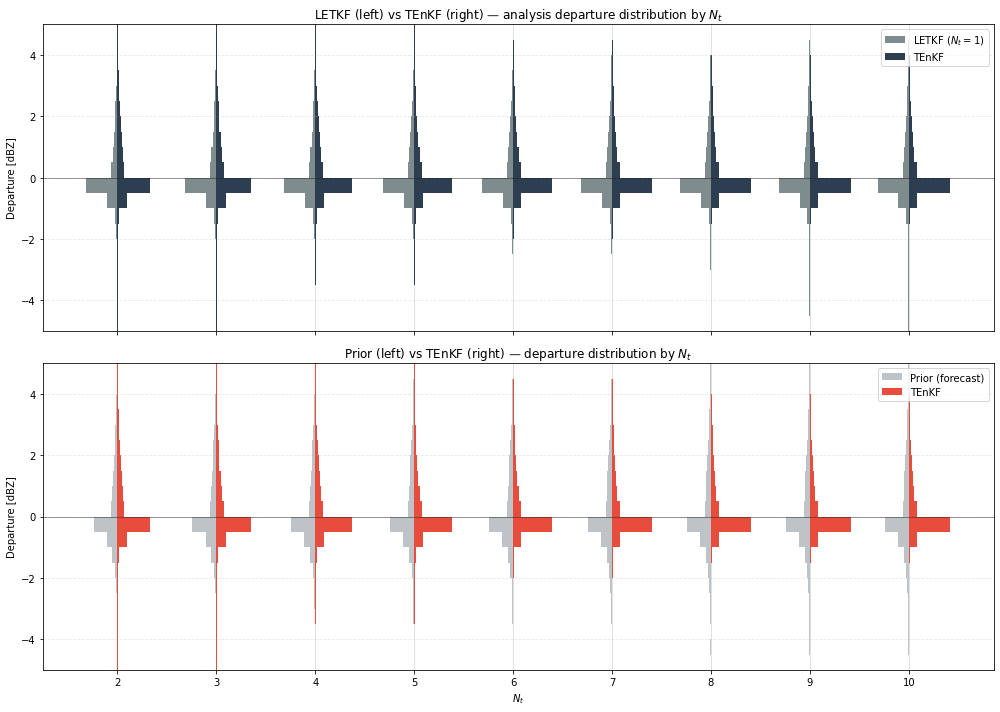

In [19]:
def hist_violin(ax, categories, left_series_list, right_series_list, bin_edges,
                 half_width=0.42, left_color='#7f8c8d', right_color='#2c3e50',
                 left_label=None, right_label=None):
    """Split histogram ('violin' shape, no KDE smoothing) at each x in `categories`:
    left half from left_series_list[i], right half from right_series_list[i]."""
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_h = np.diff(bin_edges)

    hists, max_count = [], 0.0
    for x, left, right in zip(categories, left_series_list, right_series_list):
        lh, _ = np.histogram(np.asarray(left),  bins=bin_edges, density=True)
        rh, _ = np.histogram(np.asarray(right), bins=bin_edges, density=True)
        hists.append((x, lh, rh))
        max_count = max(max_count, lh.max(), rh.max())

    for k, (x, lh, rh) in enumerate(hists):
        lw = lh / max_count * half_width
        rw = rh / max_count * half_width
        ax.barh(bin_centers, -lw, height=bin_h, left=x, color=left_color, edgecolor='none',
                label=left_label if k == 0 else None)
        ax.barh(bin_centers,  rw, height=bin_h, left=x, color=right_color, edgecolor='none',
                label=right_label if k == 0 else None)
        ax.axvline(x, color='0.85', linewidth=0.8, zorder=0)
    ax.set_xticks(categories)


ntemps_v = sorted(df_vs_prior['ntemp'].unique())
bin_edges_v = np.linspace(-20, 20, 81)  # 0.5 dBZ bins; real data has outlier tails to ~-23 dBZ

letkf_by_nt = [df_vs_prior.loc[df_vs_prior['ntemp'] == nt, 'dep_a_letkf'].dropna() for nt in ntemps_v]
prior_by_nt = [df_vs_prior.loc[df_vs_prior['ntemp'] == nt, 'dep_b'].dropna()       for nt in ntemps_v]
tenkf_by_nt = [df_vs_prior.loc[df_vs_prior['ntemp'] == nt, 'dep_a'].dropna()       for nt in ntemps_v]

# The rare (~1-3%) outlier tail reaches +/-20 dBZ (see the odd/even Nt discussion above)
# and would otherwise squash the bulk of each distribution into a sliver near zero —
# clip the *visible* range to where the actual mass is; bars for outliers just extend
# past the axis limits, they aren't dropped from the histogram itself.
y_lim_v = 5#np.nanpercentile(np.abs(pd.concat(letkf_by_nt + prior_by_nt + tenkf_by_nt)), 97)

fig, (axA, axB) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

hist_violin(axA, ntemps_v, letkf_by_nt, tenkf_by_nt, bin_edges_v,
            left_color='#7f8c8d', right_color='#2c3e50',
            left_label='LETKF ($N_t=1$)', right_label='TEnKF')
axA.set_title('LETKF (left) vs TEnKF (right) — analysis departure distribution by $N_t$')
axA.legend(loc='upper right')
axA.axhline(0, color='k', linewidth=0.8, alpha=0.5)

hist_violin(axB, ntemps_v, prior_by_nt, tenkf_by_nt, bin_edges_v,
            left_color='#bdc3c7', right_color='#e74c3c',
            left_label='Prior (forecast)', right_label='TEnKF')
axB.set_title('Prior (left) vs TEnKF (right) — departure distribution by $N_t$')
axB.legend(loc='upper right')
axB.axhline(0, color='k', linewidth=0.8, alpha=0.5)
axB.set_xlabel('$N_t$')
axB.set_ylim([-y_lim_v, y_lim_v])

for ax in (axA, axB):
    ax.set_ylabel('Departure [dBZ]')
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 4.54328616e-05, 1.90818019e-04,
        2.18077736e-04, 2.18077736e-04, 4.99761477e-04, 4.72501761e-04,
        3.90722610e-04, 8.54137798e-04, 1.44476500e-03, 1.81731446e-03,
        3.43472434e-03, 8.00527021e-03, 8.35964653e-03, 1.27757207e-02,
        1.25667295e-02, 1.93362259e-02, 2.19804184e-02, 4.01353899e-02,
        6.76677041e-02, 1.27048454e-01, 2.74705254e-01, 6.04157107e-01,
        1.51491334e-01, 1.32918380e-01, 1.15790191e-01, 9.59996365e-02,
        7.44644601e-02, 5.60550646e-02, 3.97991868e-02, 2.84591445e-02,
        1.91544944e-02, 1.31482701e-02, 8.57772427e-03, 5.74271370e-03,
        4.08895754e-03, 3.66188864e-03, 2.81683742e-03, 2.562413

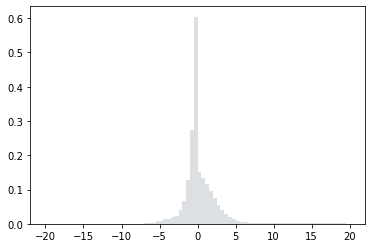

In [29]:
plt.hist(prior_by_nt[0], bins=bin_edges_v, density=True, alpha=0.5, color='#bdc3c7', label='Prior (forecast)')

In [28]:
for i in range(len(ntemps_v)):
    print(f"Nt = {ntemps_v[i]}: Prior departure distribution summary:")
    print(prior_by_nt[i].describe())

Nt = 2: Prior departure distribution summary:
count    2.005317e+06
mean     7.437654e-01
std      4.236868e+00
min     -1.050608e+01
25%     -6.357936e-01
50%     -1.291209e-01
75%      1.116638e+00
max      6.030570e+01
Name: dep_b, dtype: float64
Nt = 3: Prior departure distribution summary:
count    2.005317e+06
mean     7.437654e-01
std      4.236868e+00
min     -1.050608e+01
25%     -6.357936e-01
50%     -1.291209e-01
75%      1.116638e+00
max      6.030570e+01
Name: dep_b, dtype: float64
Nt = 4: Prior departure distribution summary:
count    2.005317e+06
mean     7.437654e-01
std      4.236868e+00
min     -1.050608e+01
25%     -6.357936e-01
50%     -1.291209e-01
75%      1.116638e+00
max      6.030570e+01
Name: dep_b, dtype: float64
Nt = 5: Prior departure distribution summary:
count    2.005317e+06
mean     7.437654e-01
std      4.236868e+00
min     -1.050608e+01
25%     -6.357936e-01
50%     -1.291209e-01
75%      1.116638e+00
max      6.030570e+01
Name: dep_b, dtype: float64


### Optimal $\alpha_s$ per Phase-Space Region

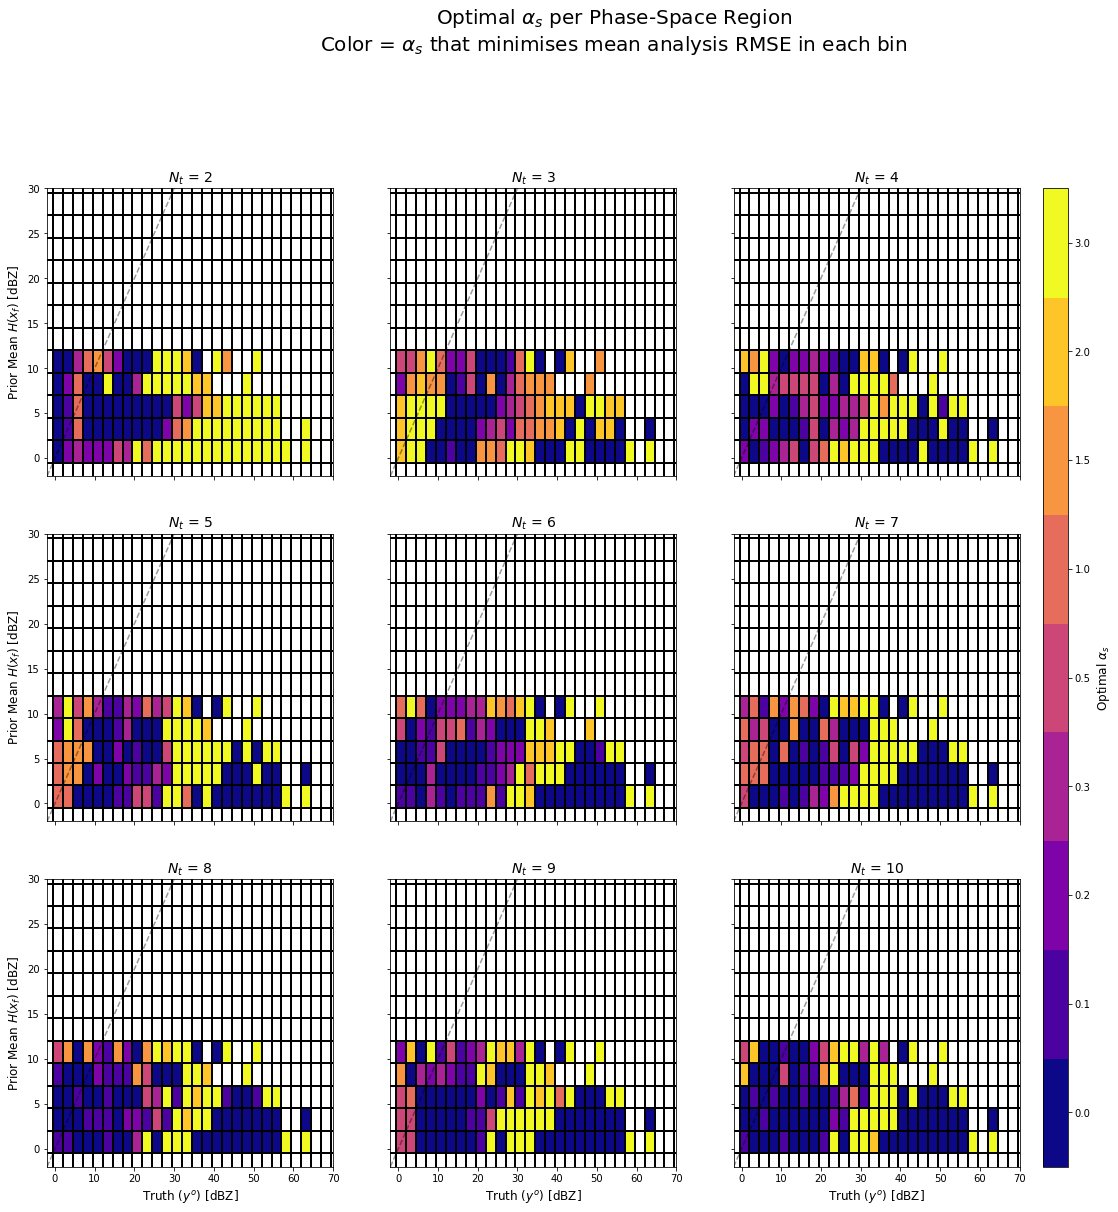

In [11]:
# ==========================================
# Optimal Alpha per Phase-Space Region
# ==========================================
from scipy.stats import binned_statistic_2d
import math
import matplotlib.colors as mcolors

BINS     = [np.arange(-3, 73, 2.5),np.arange(-3, 33, 2.5)]  # 20 bins for each dimension
XY_RANGE = [[-3, 70], [-3, 30]]

alphas_asc  = sorted(df_multi_full['alpha_s'].unique())[:-1]   # ascending for colormap indexing
ntemps_list = sorted(df_multi_full['ntemp'].unique())
n_alpha     = len(alphas_asc)
n_ntemps    = len(ntemps_list)

ncols = min(3, n_ntemps)
nrows = math.ceil(n_ntemps / ncols)

cmap_disc = plt.get_cmap('plasma', n_alpha)

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(7 * ncols, 6 * nrows),
                          sharex=True, sharey=True, squeeze=False)
fig.suptitle(
    'Optimal $\\alpha_s$ per Phase-Space Region\n'
    'Color = $\\alpha_s$ that minimises mean analysis RMSE in each bin',
    fontsize=20, y=1.02)

for idx, ntemp_val in enumerate(ntemps_list):
    row, col = divmod(idx, ncols)
    ax = axes[row][col]

    df_nt = df_multi_full[df_multi_full['ntemp'] == ntemp_val]

    # Compute mean RMSE per 2-D bin for each alpha_s
    rmse_maps = []
    for alpha_val in alphas_asc:
        df_a = df_nt[df_nt['alpha_s'] == alpha_val]
        stat, x_edges, y_edges, _ = binned_statistic_2d(
            df_a['yo_clean'], df_a['hxf_mean_obs'], df_a['rmse_a_point_obs'],
            statistic='mean', bins=BINS, range=XY_RANGE)
        rmse_maps.append(stat)

    rmse_stack = np.stack(rmse_maps, axis=0)          # shape: (n_alpha, BINS, BINS)
    all_nan    = np.all(np.isnan(rmse_stack), axis=0) # True where no data in any alpha

    # Replace NaN with inf so argmin works on partially-empty bins;
    # all-NaN bins become all-inf (argmin returns 0, masked out below).
    rmse_filled  = np.where(np.isnan(rmse_stack), np.inf, rmse_stack)
    best_idx_raw = np.argmin(rmse_filled, axis=0).astype(float)
    best_masked  = np.ma.masked_where(all_nan, best_idx_raw)

    im = ax.pcolormesh(x_edges, y_edges, best_masked.T,
                       cmap=cmap_disc, vmin=-0.5, vmax=n_alpha - 0.5,edgecolors='Black')

    ax.plot([-2, 55], [-2, 55], 'k--', alpha=0.4, linewidth=1.5)
    ax.set_xlim([-2, 70])
    ax.set_ylim([-2, 30])
    ax.set_title(f'$N_t$ = {ntemp_val}', fontsize=14)
    if row == nrows - 1: ax.set_xlabel('Truth ($y^o$) [dBZ]', fontsize=12)
    if col == 0:         ax.set_ylabel('Prior Mean $H(x_f)$ [dBZ]', fontsize=12)

# Hide unused axes in the last row
for idx in range(n_ntemps, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r][c].set_visible(False)

# Discrete colorbar labelled with actual alpha_s values
sm = plt.cm.ScalarMappable(
    cmap=cmap_disc,
    norm=mcolors.BoundaryNorm(np.arange(-0.5, n_alpha), n_alpha))
sm.set_array([])
cb = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.02, aspect=40)
cb.set_ticks(range(n_alpha))
cb.set_ticklabels([str(round(a, 3)) for a in alphas_asc])
cb.set_label('Optimal $\\alpha_s$', fontsize=12)

#plt.tight_layout()
plt.show()

<ipython-input-12-d6fc42ef0ed1>:51: RuntimeWarning: All-NaN slice encountered
  rmse_opt = np.nanmin(rmse_stack, axis=0)
<ipython-input-12-d6fc42ef0ed1>:51: RuntimeWarning: All-NaN slice encountered
  rmse_opt = np.nanmin(rmse_stack, axis=0)
<ipython-input-12-d6fc42ef0ed1>:51: RuntimeWarning: All-NaN slice encountered
  rmse_opt = np.nanmin(rmse_stack, axis=0)
<ipython-input-12-d6fc42ef0ed1>:51: RuntimeWarning: All-NaN slice encountered
  rmse_opt = np.nanmin(rmse_stack, axis=0)
<ipython-input-12-d6fc42ef0ed1>:51: RuntimeWarning: All-NaN slice encountered
  rmse_opt = np.nanmin(rmse_stack, axis=0)
<ipython-input-12-d6fc42ef0ed1>:51: RuntimeWarning: All-NaN slice encountered
  rmse_opt = np.nanmin(rmse_stack, axis=0)
<ipython-input-12-d6fc42ef0ed1>:51: RuntimeWarning: All-NaN slice encountered
  rmse_opt = np.nanmin(rmse_stack, axis=0)
<ipython-input-12-d6fc42ef0ed1>:51: RuntimeWarning: All-NaN slice encountered
  rmse_opt = np.nanmin(rmse_stack, axis=0)
<ipython-input-12-d6fc42ef0ed1>:

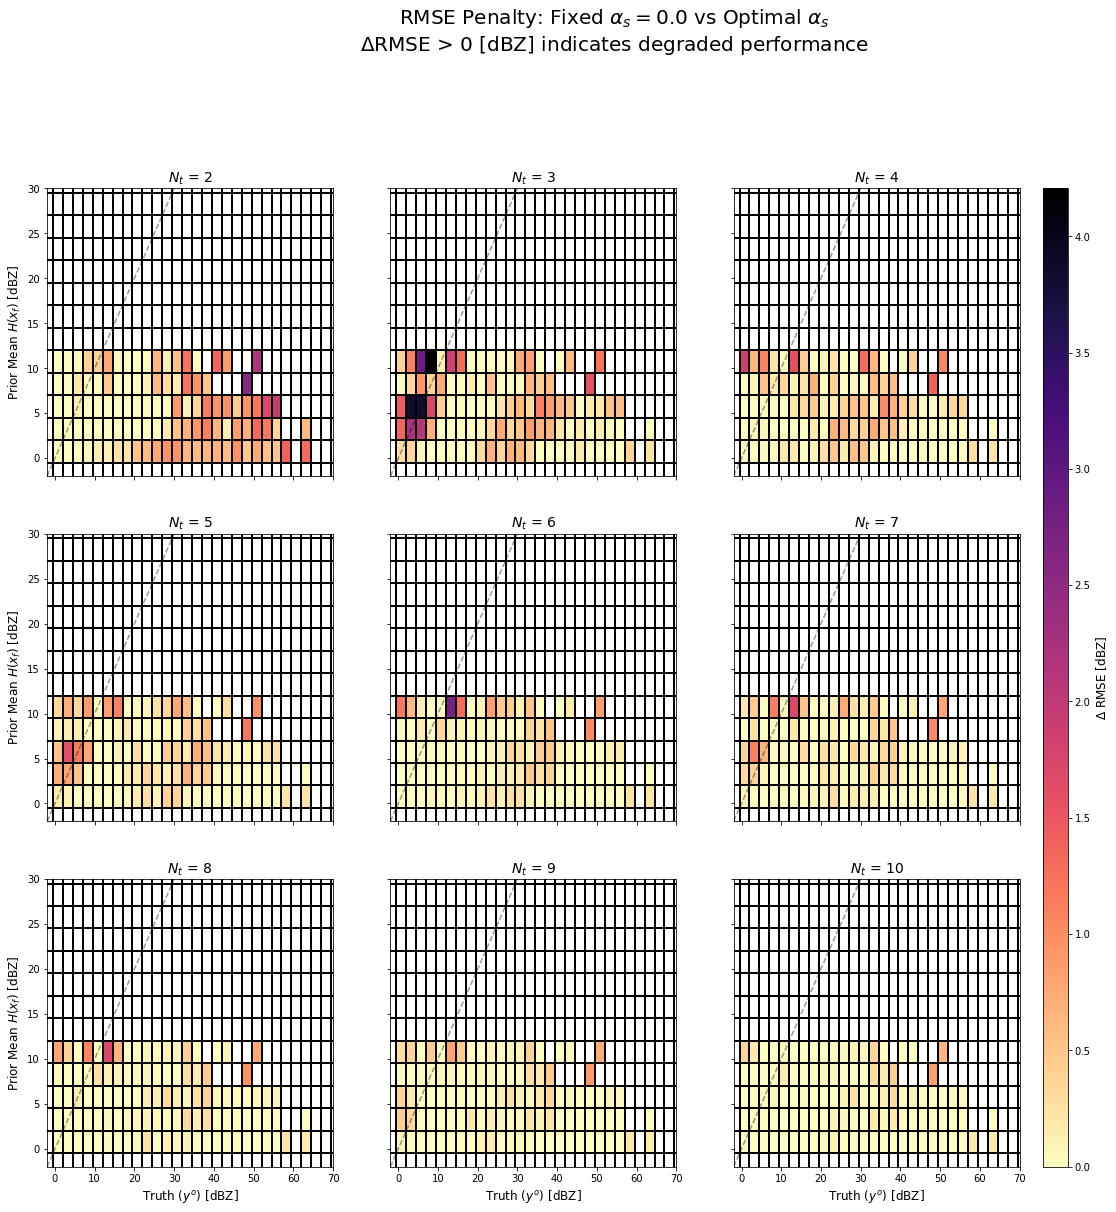

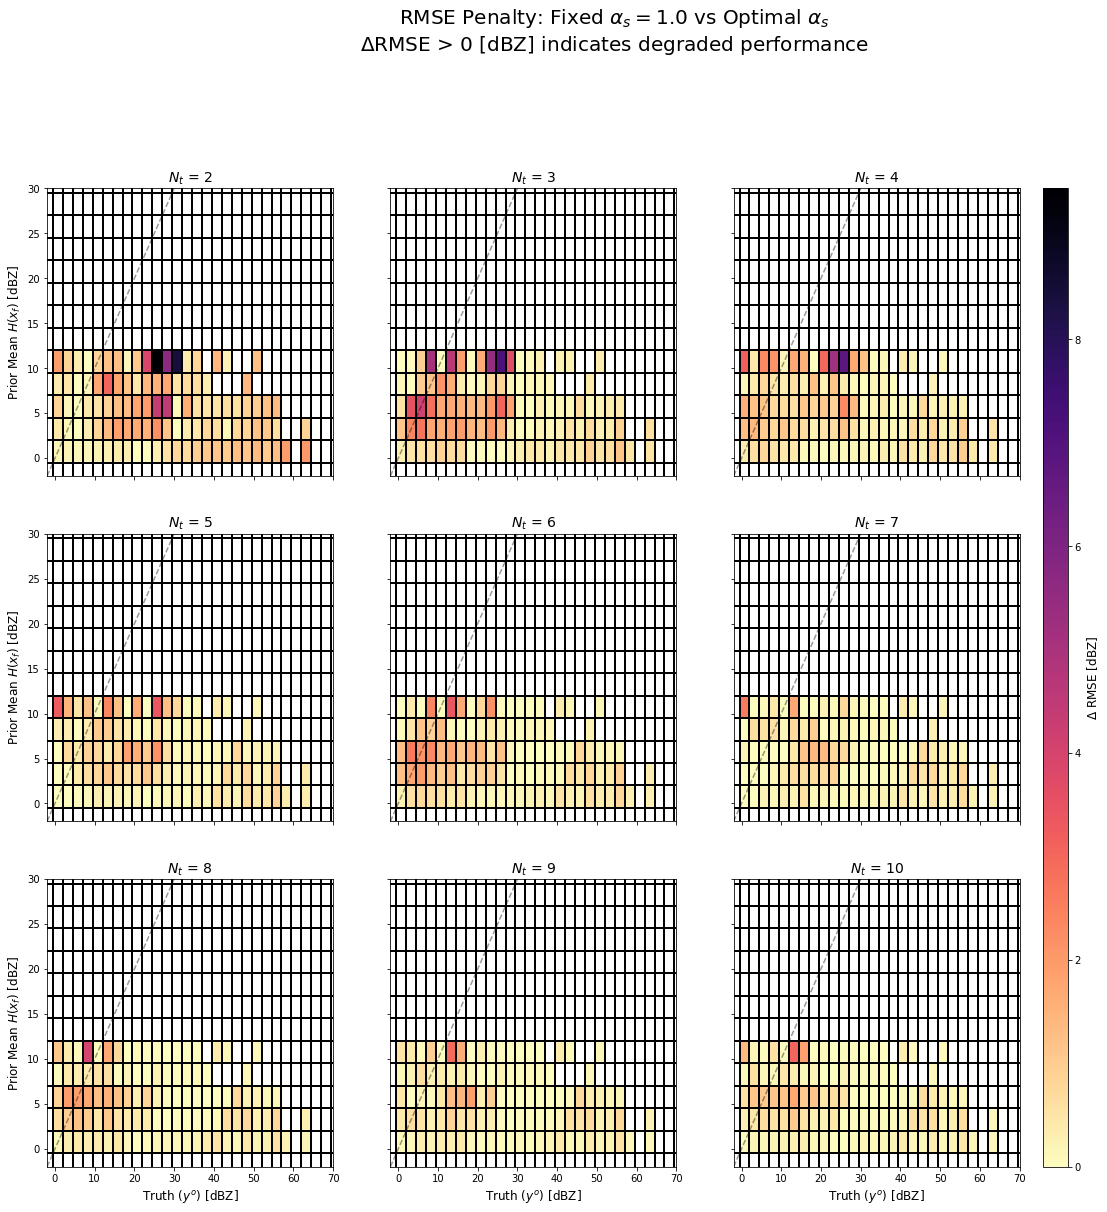

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
import math

# ==========================================
# Configuration and Bin Setup
# ==========================================
BINS     = [np.arange(-3, 73, 2.5), np.arange(-3, 33, 2.5)]
XY_RANGE = [[-3, 70], [-3, 30]]

alphas_asc  = sorted(df_multi_full['alpha_s'].unique())[:-1]
ntemps_list = sorted(df_multi_full['ntemp'].unique())
n_alpha     = len(alphas_asc)
n_ntemps    = len(ntemps_list)

ncols = min(3, n_ntemps)
nrows = math.ceil(n_ntemps / ncols)

# Locate the exact indices for alpha_s = 0 and alpha_s = 1
# (Using argmin of absolute difference to safely handle floating point precision)
alpha_array = np.array(alphas_asc)
idx_a0 = np.argmin(np.abs(alpha_array - 0.0))
idx_a1 = np.argmin(np.abs(alpha_array - 1.0))

val_a0 = alphas_asc[idx_a0]
val_a1 = alphas_asc[idx_a1]

# ==========================================
# 1. Pre-compute all Binned Statistics
# ==========================================
# Storing the stacks prevents running the expensive binning operation twice
binned_data = {}
for ntemp_val in ntemps_list:
    df_nt = df_multi_full[df_multi_full['ntemp'] == ntemp_val]
    
    rmse_maps = []
    for alpha_val in alphas_asc:
        df_a = df_nt[df_nt['alpha_s'] == alpha_val]
        stat, x_edges, y_edges, _ = binned_statistic_2d(
            df_a['yo_clean'], df_a['hxf_mean_obs'], df_a['rmse_a_point_obs'],
            statistic='mean', bins=BINS, range=XY_RANGE)
        rmse_maps.append(stat)
        
    rmse_stack = np.stack(rmse_maps, axis=0)          
    all_nan    = np.all(np.isnan(rmse_stack), axis=0) 
    
    # Calculate optimal RMSE across alpha dimension (ignoring NaNs)
    # Suppress warnings for all-NaN slices, we mask them out later anyway
    with np.errstate(all='ignore'):
        rmse_opt = np.nanmin(rmse_stack, axis=0)
    
    binned_data[ntemp_val] = {
        'stack': rmse_stack,
        'rmse_opt': rmse_opt,
        'x_edges': x_edges,
        'y_edges': y_edges,
        'all_nan': all_nan
    }

# ==========================================
# 2. Plotting Function for the RMSE Penalty
# ==========================================
def plot_rmse_penalty(target_idx, target_val):
    fig, axes = plt.subplots(nrows, ncols, 
                             figsize=(7 * ncols, 6 * nrows), 
                             sharex=True, sharey=True, squeeze=False)
    
    fig.suptitle(f'RMSE Penalty: Fixed $\\alpha_s = {target_val}$ vs Optimal $\\alpha_s$\n'
                 '$\\Delta$RMSE > 0 [dBZ] indicates degraded performance', 
                 fontsize=20, y=1.02)

    # Track maximum penalty to standardize the colorbar across subplots
    max_penalty_global = 0

    # First pass to find global max for consistent color scaling
    for ntemp_val in ntemps_list:
        data = binned_data[ntemp_val]
        rmse_target  = data['stack'][target_idx]
        penalty      = rmse_target - data['rmse_opt']
        # Ignore NaNs when finding the max
        max_penalty_global = max(max_penalty_global, np.nanmax(penalty))

    # Second pass to plot
    for idx, ntemp_val in enumerate(ntemps_list):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        data = binned_data[ntemp_val]

        rmse_target = data['stack'][target_idx]
        penalty     = rmse_target - data['rmse_opt']
        
        # Mask out bins that have no data at all
        penalty_masked = np.ma.masked_where(data['all_nan'], penalty)

        # Using 'magma_r' or 'Reds' so darker colors = worse penalty
        im = ax.pcolormesh(data['x_edges'], data['y_edges'], penalty_masked.T, 
                           cmap='magma_r', vmin=0, vmax=max_penalty_global, edgecolors='Black')

        ax.plot([-2, 55], [-2, 55], 'k--', alpha=0.4, linewidth=1.5)
        ax.set_xlim([-2, 70])
        ax.set_ylim([-2, 30])
        ax.set_title(f'$N_t$ = {ntemp_val}', fontsize=14)
        
        if row == nrows - 1: ax.set_xlabel('Truth ($y^o$) [dBZ]', fontsize=12)
        if col == 0:         ax.set_ylabel('Prior Mean $H(x_f)$ [dBZ]', fontsize=12)

    # Hide unused axes
    for idx in range(n_ntemps, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r][c].set_visible(False)

    # Continuous colorbar for the RMSE difference
    cb = fig.colorbar(im, ax=axes.ravel().tolist(), pad=0.02, aspect=40)
    cb.set_label('$\\Delta$ RMSE [dBZ]', fontsize=12)

    plt.show()

# ==========================================
# 3. Generate the Figures
# ==========================================
# Figure 1: Penalty for using alpha_s = 0
plot_rmse_penalty(target_idx=idx_a0, target_val=val_a0)

# Figure 2: Penalty for using alpha_s = 1
plot_rmse_penalty(target_idx=idx_a1, target_val=val_a1)

### CRPS / Skewness / Kurtosis — Nerger (2022) diagnostics (prototype)

Nerger (2022) ("Data assimilation for nonlinear systems with a hybrid nonlinear Kalman
ensemble transform filter") uses three ensemble diagnostics — CRPS, mean absolute
skewness, and mean absolute kurtosis — to detect non-Gaussianity and drive an adaptive
hybrid-filter weight. This section prototypes the same three statistics for this project.

**Why this can be done without a cluster re-run (for the forecast/background side only):**
none of the saved sweep `.npz` files keep the per-member ensemble (only mean/std-derived
scalars), so the *analysis* side genuinely needs a code change + re-run. But the *forecast*
ensemble doesn't need reconstructing from a re-run at all — `_setup()` in
`src/runners/run_experiment.py` builds it as a literal slice of the untouched
`state_ensemble` array in the `3D_subsets_..._GUES_..._` prepared file (all 60 members
except whichever one is `tm`). Since `tm`, `i,j,k`, and `prior_size` are already columns/
config values we have, we can rebuild the exact forecast ensemble the pipeline used, with
zero cluster time, and cross-check it against the already-saved `hxf_mean_obs`/
`spread_f_obs`/`rmse_f_point_obs` columns below.

In [13]:
def ensemble_skew(ens, axis=-1):
    """Nerger (2022) Eq. 25 sample skewness along `axis` (NOT scipy's default normalization)."""
    Ne = ens.shape[axis]
    dev = ens - ens.mean(axis=axis, keepdims=True)
    m3 = (dev ** 3).mean(axis=axis)
    var_unbiased = (dev ** 2).sum(axis=axis) / (Ne - 1)
    return m3 / var_unbiased ** 1.5


def ensemble_kurt(ens, axis=-1):
    """Nerger (2022) Eq. 26 sample excess kurtosis along `axis` (NOT scipy's default normalization)."""
    Ne = ens.shape[axis]
    dev = ens - ens.mean(axis=axis, keepdims=True)
    m4 = (dev ** 4).mean(axis=axis)
    m2 = (dev ** 2).mean(axis=axis)
    return m4 / m2 ** 2 - 3.0


def crps_ensemble(ens, truth, axis=-1):
    """Empirical ensemble CRPS (Gneiting & Raftery 2007): mean|x_i-y| - 0.5*mean|x_i-x_j|.
    O(Ne^2) pairwise term — fine at the single-point/subdomain scale used here."""
    ens = np.moveaxis(ens, axis, -1)
    term1 = np.abs(ens - truth[..., np.newaxis]).mean(axis=-1)
    term2 = np.abs(ens[..., :, None] - ens[..., None, :]).mean(axis=(-2, -1))
    return term1 - 0.5 * term2

#### Validate skew/kurt against exact closed-form limiting ensembles

Nerger's Appendix A gives three point-mass ensembles with known extreme skew/kurtosis, but
states the tabulated limits only hold *approximately* (~5-6% deviation at `Ne=100`, exact only
for one specific case). Rather than trust an approximate tolerance, the closed forms below were
re-derived by hand directly from Eq. 25/26 for each recipe (algebra confirmed independently, not
copied from the paper's table), so the checks below assert **exact** equality:

- **one low outlier** (`Ne-1` members at `a`, one at `a-d`): skew `= -(Ne-1)(Ne-2)/Ne^1.5`, kurt `= [(Ne-1)^3+1]/[Ne(Ne-1)] - 3`
- **two symmetric outliers in a cluster** (`Ne-2` at `a`, one at `a-d`, one at `a+d`): skew `= 0`, kurt `= Ne/2 - 3` exactly (not just in the large-`Ne` limit)
- **two equal-size groups** (`Ne/2` at `a-d`, `Ne/2` at `a+d`, needs even `Ne`): skew `= 0`, kurt `= -2` exactly

(Note: the two-outlier and two-group cases are the ones the paper's Table A1 rows are
labelled "max. kurt" / "min. kurt" — as extracted here their listed kurt-limit column doesn't
match their own listed recipe when evaluated exactly, most likely a table/PDF-extraction
artifact; the exact algebra above is self-contained and doesn't depend on that table.)

In [14]:
def check_ensemble_stats_exact(Ne, d=1.0, a=0.0):
    """Assert ensemble_skew/ensemble_kurt against the hand-derived exact closed forms above."""
    # one low outlier
    x = np.full(Ne, a); x[0] = a - d
    sk_exact = -(Ne - 1) * (Ne - 2) / Ne ** 1.5
    ku_exact = ((Ne - 1) ** 3 + 1) / (Ne * (Ne - 1)) - 3
    assert np.isclose(ensemble_skew(x), sk_exact)
    assert np.isclose(ensemble_kurt(x), ku_exact)

    # two symmetric outliers in a cluster
    x = np.full(Ne, a); x[0] = a - d; x[1] = a + d
    ku_exact2 = Ne / 2 - 3
    assert np.isclose(ensemble_skew(x), 0.0, atol=1e-8)
    assert np.isclose(ensemble_kurt(x), ku_exact2)

    # two equal-size groups — only exact for even Ne (odd Ne can't split evenly)
    if Ne % 2 == 0:
        x = np.concatenate([np.full(Ne // 2, a - d), np.full(Ne // 2, a + d)])
        assert np.isclose(ensemble_skew(x), 0.0, atol=1e-8)
        assert np.isclose(ensemble_kurt(x), -2.0)

    print(f"Ne={Ne:>3d}: OK  (one-outlier skew={sk_exact:7.4f} kurt={ku_exact:7.4f}, "
          f"two-outlier kurt={ku_exact2:7.4f})")


for _Ne in (24, 25, 59, 100):   # 59 = Ne actually used in these sweeps (60 members minus tm)
    check_ensemble_stats_exact(_Ne)

# Degenerate-ensemble CRPS sanity: a spread-0 ensemble's CRPS must equal the plain abs error
_deg = np.full(40, 3.0)
assert np.isclose(crps_ensemble(_deg, np.array(5.0)), 2.0)
print("CRPS degenerate-ensemble check: OK (matches |3-5|=2.0)")

Ne= 24: OK  (one-outlier skew=-4.3036 kurt=19.0435, two-outlier kurt= 9.0000)
Ne= 25: OK  (one-outlier skew=-4.4160 kurt=20.0417, two-outlier kurt= 9.5000)
Ne= 59: OK  (one-outlier skew=-7.2950 kurt=54.0172, two-outlier kurt=26.5000)
Ne=100: OK  (one-outlier skew=-9.7020 kurt=95.0101, two-outlier kurt=47.0000)
CRPS degenerate-ensemble check: OK (matches |3-5|=2.0)


#### Reconstruct real forecast ensembles and cross-check against saved sweep metrics

For a handful of real storm points (highest `yo_clean` at `tm=0`), rebuild the exact
forecast ensemble `_setup()` used from the untouched GUES prepared file, then confirm
`hxf_mean_obs` / `spread_f_obs` / `rmse_f_point_obs` reproduce exactly — before trusting
the new `skew`/`kurt`/`crps` values computed alongside them.

In [15]:
import sys
_SRC = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/src"
for _p in (_SRC, _SRC + "/runners"):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import run_experiment as run_exp  # needs the `intermediate_exp` kernel (compiled Fortran ext)

VAR_IDX = {"qg": 0, "qr": 1, "qs": 2, "T": 3, "P": 4, "u": 5, "v": 6, "w": 7}
TM_PROTO = 0
PRIOR_SIZE = 60  # matches sweep.prior_size in WS_tune_5min_1800_config.yaml

# Local mirror of this run's paths.prepared (WS_tune_5min_1800_config.yaml points at
# /home/jorge.gacitua/salidas/... — a cluster-only mount; same file lives here under data/)
_prepared = (
    "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/"
    "3D_subsets_20240319_GUES_SINGLECONF_20240319180000_1HR/subset_20240319180000.npz"
)
_ens_all = np.load(_prepared)["state_ensemble"]  # (307, 451, 11, 60, 8)
_Ne_tot = _ens_all.shape[3]
_all_others = [m for m in range(_Ne_tot) if m != TM_PROTO][:PRIOR_SIZE]

storm_rows = (
    df_tenkf_full[(df_tenkf_full["tm"] == TM_PROTO) & (df_tenkf_full["ntemp"] == 1)]
    .sort_values("yo_clean", ascending=False)
    .drop_duplicates(["i", "j", "k"])
    .head(5)
)

proto_rows = []
for _, row in storm_rows.iterrows():
    i0, j0, k0 = int(row["i"]), int(row["j"]), int(row["k"])
    xf_pt = _ens_all[i0, j0, k0, _all_others, :]                      # (Ne, 8) raw state
    ens_hx = run_exp._calc_hx_domain(
        xf_pt[np.newaxis, np.newaxis, np.newaxis, :, :], VAR_IDX, dbz_min=0.0
    )[0, 0, 0, :]                                                      # (Ne,) reflectivity
    yo_clean = float(row["yo_clean"])

    proto_rows.append(dict(
        i=i0, j=j0, k=k0, yo_clean=yo_clean,
        hxf_mean_recon=ens_hx.mean(), hxf_mean_saved=row["hxf_mean_obs"],
        spread_recon=ens_hx.std(ddof=1), spread_saved=row["spread_f_obs"],
        abs_dep_b_recon=abs(yo_clean - ens_hx.mean()), rmse_f_point_saved=row["rmse_f_point_obs"],
        skew_obs=ensemble_skew(ens_hx), kurt_obs=ensemble_kurt(ens_hx),
        crps_obs=crps_ensemble(ens_hx, np.array(yo_clean)),
        skew_w=ensemble_skew(xf_pt[:, VAR_IDX["w"]]), kurt_w=ensemble_kurt(xf_pt[:, VAR_IDX["w"]]),
    ))

proto_df = pd.DataFrame(proto_rows)
pd.testing.assert_series_equal(proto_df["hxf_mean_recon"], proto_df["hxf_mean_saved"],
                                check_names=False, check_exact=False, rtol=1e-4)
pd.testing.assert_series_equal(proto_df["spread_recon"], proto_df["spread_saved"],
                                check_names=False, check_exact=False, rtol=1e-4)
print("Reconstruction matches saved hxf_mean_obs/spread_f_obs to 1e-4 — Phase 0 validated.\n")
proto_df

Reconstruction matches saved hxf_mean_obs/spread_f_obs to 1e-4 — Phase 0 validated.



,i,j,k,yo_clean,hxf_mean_recon,hxf_mean_saved,spread_recon,spread_saved,abs_dep_b_recon,rmse_f_point_saved,skew_obs,kurt_obs,crps_obs,skew_w,kurt_w
0,280,260,2,49.777927,1.601716,1.601716,6.070317,6.070317,48.176211,48.176212,3.895005,14.615007,46.672457,1.969946,8.437632
1,280,260,1,49.373192,1.333842,1.333842,5.052276,5.052276,48.039350,48.039349,3.835466,14.303657,46.785716,0.558052,1.645636
2,280,260,0,48.859978,1.128155,1.128155,3.952315,3.952315,47.731822,47.731823,3.742825,14.691987,46.681782,0.290715,1.121587
3,280,260,3,48.787102,1.299857,1.299857,5.827684,5.827684,47.487244,47.487244,4.344507,18.857888,46.245011,3.395591,17.993168
4,280,260,4,47.583618,0.291398,0.291398,1.511497,1.511497,47.292220,47.292221,5.971898,38.878092,47.011173,0.973779,7.805963
